<a href="https://colab.research.google.com/github/kej534923-maker/card-1995-iv-replication/blob/main/03_Extension_and_Results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Extension and Results: Heterogeneous Returns to Schooling

This notebook extends Card (1995), *Using Geographic Variation in College Proximity to Estimate the Return to Schooling*, by testing whether the return to schooling differs across demographic groups.

Specifically, I estimate heterogeneous treatment effects (HTE) by interacting schooling with race (`black`) and region (`south66`) within an IV framework. The baseline specification uses proximity to a four-year college (`nearc4`) as an instrument for schooling (`ed76`), and the extension instruments the interaction terms as well.

In [1]:
!pip install linearmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 9.7 MB/s eta 0:00:00


In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from linearmodels.iv import IV2SLS

In [3]:
from google.colab import files
uploaded = files.upload()

Saving nls.dat to nls.dat
Saving read1.sas to read1.sas


In [4]:
def extract_varlist_from_sas(path="read1.sas"):
    text = open(path, "r", errors="ignore").read()

    # match the actual INPUT block at line start
    m = re.search(r"(?mi)^\s*input\s+(.*?);", text, flags=re.DOTALL)
    if not m:
        raise ValueError("Cannot find INPUT block in read1.sas")

    block = m.group(1)

    # remove SAS comments
    block = re.sub(r"/\*.*?\*/", " ", block, flags=re.DOTALL)

    # extract variable names
    tokens = re.findall(r"\b[A-Za-z_][A-Za-z0-9_]*\b", block)

    return tokens

colnames = extract_varlist_from_sas("read1.sas")

print("Number of variables:", len(colnames))
print("First 10:", colnames[:10])
print("Last 5:", colnames[-5:])

Number of variables: 52
First 10: ['id', 'nearc2', 'nearc4', 'nearc4a', 'nearc4b', 'ed76', 'ed66', 'age76', 'daded', 'nodaded']
Last 5: ['iq', 'marsta76', 'marsta78', 'marsta80', 'libcrd14']


In [5]:
df = pd.read_csv(
    "nls.dat",
    sep=r"\s+",
    header=None,
    names=colnames,
    engine="python"
)

print("Raw shape:", df.shape)
df.head()

Raw shape: (3613, 52)


,id,nearc2,nearc4,nearc4a,nearc4b,ed76,ed66,age76,daded,nodaded,...,noint80,enroll76,enroll78,enroll80,kww,iq,marsta76,marsta78,marsta80,libcrd14
0,2,0,0,0,0,7,5,29,9.94,1,...,0,0,0,0,15,.,1,1,1,0
1,3,0,0,0,0,12,11,27,8.00,0,...,0,0,0,0,35,93,1,4,4,1
2,4,0,0,0,0,12,12,34,14.00,0,...,1,0,.,.,42,103,1,.,.,1
3,5,1,1,1,0,11,11,27,11.00,0,...,0,0,.,0,25,88,1,.,5,1
4,6,1,1,1,0,12,12,34,8.00,0,...,1,0,0,.,34,108,1,1,.,0


In [6]:
# Replace SAS-style "." missing values with NaN
df = df.replace(".", np.nan)

# Convert all columns to numeric where possible
df = df.apply(pd.to_numeric, errors="coerce")

# Construct age squared
df["age76_sq"] = df["age76"] ** 2

print(df.dtypes.head(10))

id           int64
nearc2       int64
nearc4       int64
nearc4a      int64
nearc4b      int64
ed76         int64
ed66         int64
age76        int64
daded      float64
nodaded      int64
dtype: object


In [7]:
analysis_vars = [
    "lwage76",
    "ed76",
    "nearc4",
    "black",
    "south66",
    "smsa66r",
    "age76",
    "age76_sq"
]

df_reg = df[analysis_vars].dropna().copy()

print("Analysis sample shape:", df_reg.shape)
df_reg.head()

Analysis sample shape: (3010, 8)


,lwage76,ed76,nearc4,black,south66,smsa66r,age76,age76_sq
0,6.306275,7,0,1,0,1,29,841
1,6.175867,12,0,0,0,1,27,729
2,6.580639,12,0,0,0,1,34,1156
3,5.521461,11,1,0,0,1,27,729
4,6.591674,12,1,0,0,1,34,1156


In [8]:
desc_vars = ["lwage76", "ed76", "nearc4", "black", "south66", "smsa66r", "age76", "age76_sq"]
desc_table = df_reg[desc_vars].describe()
desc_table

,lwage76,ed76,nearc4,black,south66,smsa66r,age76,age76_sq
count,3010.000000,3010.000000,3010.000000,3010.000000,3010.000000,3010.000000,3010.000000,3010.000000
mean,6.261832,13.263455,0.682060,0.233555,0.414286,0.649502,28.119601,800.549502
std,0.443798,2.676913,0.465753,0.423162,0.492680,0.477205,3.137004,180.748395
min,4.605170,1.000000,0.000000,0.000000,0.000000,0.000000,24.000000,576.000000
25%,5.976985,12.000000,0.000000,0.000000,0.000000,0.000000,25.000000,625.000000
50%,6.286928,13.000000,1.000000,0.000000,0.000000,1.000000,28.000000,784.000000
75%,6.563503,16.000000,1.000000,0.000000,1.000000,1.000000,31.000000,961.000000
max,7.784889,18.000000,1.000000,1.000000,1.000000,1.000000,34.000000,1156.000000


## Baseline IV Model

I first estimate the baseline IV model from Card (1995), using `nearc4` as an instrument for schooling (`ed76`). This provides the benchmark causal return to schooling before introducing heterogeneous treatment effects.


In [9]:
X_ols = df_reg[["ed76", "black", "south66", "smsa66r", "age76", "age76_sq"]]
X_ols = sm.add_constant(X_ols)

y = df_reg["lwage76"]

ols_model = sm.OLS(y, X_ols).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                lwage76   R-squared:                       0.258
Model:                            OLS   Adj. R-squared:                  0.256
Method:                 Least Squares   F-statistic:                     174.0
Date:                Sun, 22 Mar 2026   Prob (F-statistic):          2.13e-190
Time:                        14:48:35   Log-Likelihood:                -1376.2
No. Observations:                3010   AIC:                             2766.
Df Residuals:                    3003   BIC:                             2808.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9490      0.654      4.506      0.0

In [10]:
X_first = df_reg[["nearc4", "black", "south66", "smsa66r", "age76", "age76_sq"]]
X_first = sm.add_constant(X_first)

first_stage = sm.OLS(df_reg["ed76"], X_first).fit()
print(first_stage.summary())

                            OLS Regression Results                            
Dep. Variable:                   ed76   R-squared:                       0.105
Model:                            OLS   Adj. R-squared:                  0.103
Method:                 Least Squares   F-statistic:                     58.59
Date:                Sun, 22 Mar 2026   Prob (F-statistic):           8.17e-69
Time:                        14:48:49   Log-Likelihood:                -7067.7
No. Observations:                3010   AIC:                         1.415e+04
Df Residuals:                    3003   BIC:                         1.419e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.7629      4.336     -0.637      0.5

In [11]:
df_reg["ed_hat"] = first_stage.predict(X_first)

X_second = df_reg[["ed_hat", "black", "south66", "smsa66r", "age76", "age76_sq"]]
X_second = sm.add_constant(X_second)

manual_2sls = sm.OLS(df_reg["lwage76"], X_second).fit()
print(manual_2sls.summary())

                            OLS Regression Results                            
Dep. Variable:                lwage76   R-squared:                       0.214
Model:                            OLS   Adj. R-squared:                  0.212
Method:                 Least Squares   F-statistic:                     136.1
Date:                Sun, 22 Mar 2026   Prob (F-statistic):          7.52e-153
Time:                        14:49:02   Log-Likelihood:                -1463.2
No. Observations:                3010   AIC:                             2940.
Df Residuals:                    3003   BIC:                             2983.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.1156      0.682      4.570      0.0

In [12]:
baseline_iv = IV2SLS.from_formula(
    "lwage76 ~ 1 + black + south66 + smsa66r + age76 + age76_sq + [ed76 ~ nearc4]",
    data=df_reg
).fit()

print(baseline_iv.summary)

                          IV-2SLS Estimation Summary                          
Dep. Variable:                lwage76   R-squared:                      0.1248
Estimator:                    IV-2SLS   Adj. R-squared:                 0.1230
No. Observations:                3010   F-statistic:                    789.68
Date:                Sun, Mar 22 2026   P-value (F-stat)                0.0000
Time:                        14:49:33   Distribution:                  chi2(6)
Cov. Estimator:                robust                                         
                                                                              
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
Intercept      3.1156     0.7206     4.3234     0.0000      1.7032      4.5280
black         -0.0904     0.0580    -1.5603     0.11

## Extension: Heterogeneous Treatment Effects

The baseline model assumes that the return to schooling is homogeneous across individuals. To relax this assumption, I allow the return to schooling to vary by race (`black`) and region (`south66`).

I include interaction terms between schooling and these demographic indicators. Because these interaction terms are also endogenous, I instrument them using interactions between the instrument (`nearc4`) and the same demographic indicators.

In [13]:
# Endogenous interaction terms
df_reg["ed76_black"] = df_reg["ed76"] * df_reg["black"]
df_reg["ed76_south"] = df_reg["ed76"] * df_reg["south66"]

# Instrument interaction terms
df_reg["nearc4_black"] = df_reg["nearc4"] * df_reg["black"]
df_reg["nearc4_south"] = df_reg["nearc4"] * df_reg["south66"]

df_reg[["ed76", "black", "south66", "ed76_black", "ed76_south", "nearc4_black", "nearc4_south"]].head()

,ed76,black,south66,ed76_black,ed76_south,nearc4_black,nearc4_south
0,7,1,0,7,0,0,0
1,12,0,0,0,0,0,0
2,12,0,0,0,0,0,0
3,11,0,0,0,0,0,0
4,12,0,0,0,0,0,0


In [14]:
hte_model = IV2SLS.from_formula(
    """
    lwage76 ~ 1 + black + south66 + smsa66r + age76 + age76_sq
    + [ed76 + ed76_black + ed76_south ~ nearc4 + nearc4_black + nearc4_south]
    """,
    data=df_reg
).fit()

print(hte_model.summary)

                          IV-2SLS Estimation Summary                          
Dep. Variable:                lwage76   R-squared:                     -0.1956
Estimator:                    IV-2SLS   Adj. R-squared:                -0.1988
No. Observations:                3010   F-statistic:                    706.92
Date:                Sun, Mar 22 2026   P-value (F-stat)                0.0000
Time:                        14:50:35   Distribution:                  chi2(8)
Cov. Estimator:                robust                                         
                                                                              
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
Intercept      3.6370     1.1726     3.1017     0.0019      1.3388      5.9352
black          1.8558     3.1446     0.5901     0.55

In [15]:
coef_names = ["ed76", "ed76_black", "ed76_south"]

hte_coef_table = pd.DataFrame({
    "variable": coef_names,
    "coef": [hte_model.params[v] for v in coef_names],
    "se": [hte_model.std_errors[v] for v in coef_names],
    "p_value": [hte_model.pvalues[v] for v in coef_names]
})

hte_coef_table["lower_95"] = hte_coef_table["coef"] - 1.96 * hte_coef_table["se"]
hte_coef_table["upper_95"] = hte_coef_table["coef"] + 1.96 * hte_coef_table["se"]

hte_coef_table

,variable,coef,se,p_value,lower_95,upper_95
0,ed76,0.089895,0.059244,0.129172,-0.026223,0.206014
1,ed76_black,-0.150851,0.241804,0.532721,-0.624787,0.323085
2,ed76_south,0.154722,0.223779,0.489311,-0.283885,0.593330


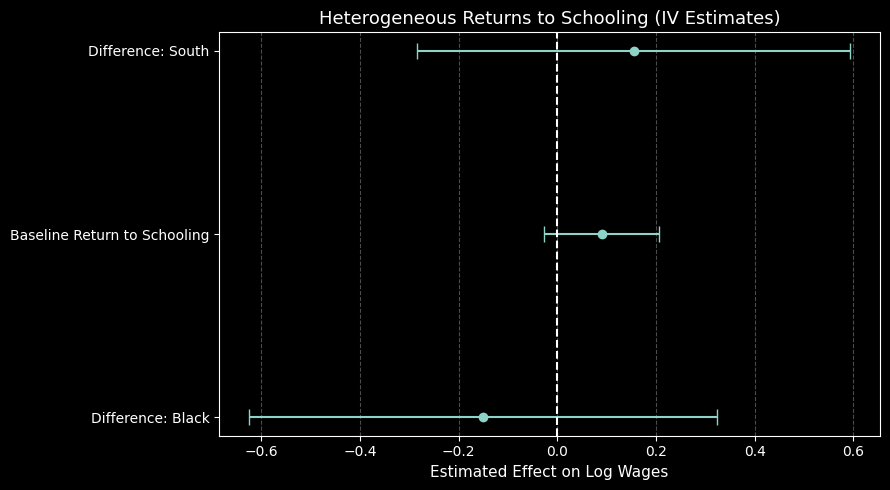

In [20]:
import matplotlib.pyplot as plt

plot_df = hte_coef_table.copy()

label_map = {
    "ed76": "Baseline Return to Schooling",
    "ed76_black": "Difference: Black",
    "ed76_south": "Difference: South"
}

plot_df["label"] = plot_df["variable"].map(label_map)

plot_df = plot_df.sort_values("coef")

# Dark theme
plt.style.use("dark_background")

plt.figure(figsize=(9, 5))

plt.errorbar(
    x=plot_df["coef"],
    y=plot_df["label"],
    xerr=1.96 * plot_df["se"],
    fmt='o',
    capsize=6
)

plt.axvline(x=0, linestyle='--')


plt.title("Heterogeneous Returns to Schooling (IV Estimates)", fontsize=13)
plt.xlabel("Estimated Effect on Log Wages", fontsize=11)
plt.ylabel("")

plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
baseline_return = hte_model.params["ed76"]
black_diff = hte_model.params["ed76_black"]
south_diff = hte_model.params["ed76_south"]

return_nonblack_nonsouth = baseline_return
return_black = baseline_return + black_diff
return_south = baseline_return + south_diff

subgroup_returns = pd.DataFrame({
    "Group": [
        "Baseline (non-Black, non-South)",
        "Black",
        "South"
    ],
    "Estimated_Return_to_Schooling": [
        return_nonblack_nonsouth,
        return_black,
        return_south
    ],
    "Approx_Percent_Return": [
        return_nonblack_nonsouth * 100,
        return_black * 100,
        return_south * 100
    ]
})

subgroup_returns

,Group,Estimated_Return_to_Schooling,Approx_Percent_Return
0,"Baseline (non-Black, non-South)",0.089895,8.989533
1,Black,-0.060956,-6.095589
2,South,0.244617,24.461750


In [18]:
comparison_table = pd.DataFrame({
    "Model": ["OLS", "Manual 2SLS", "Baseline IV2SLS", "HTE IV Baseline Effect"],
    "Coefficient": [
        ols_model.params["ed76"],
        manual_2sls.params["ed_hat"],
        baseline_iv.params["ed76"],
        hte_model.params["ed76"]
    ]
})

comparison_table["Approx_Percent_Return"] = comparison_table["Coefficient"] * 100
comparison_table

,Model,Coefficient,Approx_Percent_Return
0,OLS,0.037428,3.742763
1,Manual 2SLS,0.101209,10.120917
2,Baseline IV2SLS,0.101209,10.120917
3,HTE IV Baseline Effect,0.089895,8.989533


## Executive Summary

The baseline IV estimate suggests that one additional year of schooling increases log wages by a substantially larger amount than the OLS estimate, consistent with the original Card (1995) argument that OLS may understate the causal return to schooling due to endogeneity.

The extension shows that the return to schooling is not necessarily homogeneous across groups. By allowing schooling to interact with race and region, the IV estimates suggest that some demographic groups may experience different marginal returns to education. This does not overturn the original paper’s main finding that schooling raises wages, but it adds important nuance by showing that the magnitude of the return may vary across populations.

## Conclusion

This extension supports the original paper’s core conclusion that education has a positive causal effect on wages. However, it also suggests that the return to schooling may differ by race and region, which is consistent with the idea that labor market opportunities and constraints are not evenly distributed across individuals.

More broadly, this extension demonstrates the value of moving beyond average treatment effects. A single coefficient may mask important heterogeneity, and incorporating interaction terms within an IV framework provides a more policy-relevant understanding of who benefits most from additional schooling.

In [21]:
hte_coef_table.to_csv("hte_coefficients.csv", index=False)
subgroup_returns.to_csv("hte_subgroup_returns.csv", index=False)
comparison_table.to_csv("baseline_vs_hte_comparison.csv", index=False)